<a href="https://colab.research.google.com/github/esprydi/sentimen-analisis-shopee-playstore/blob/master/Sentiment_Analisis_shopee_Playstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-play-scraper

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#Scraping Dataset

In [2]:
#mengimpor pustaka google_play_scrapper

from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi
scrapreview = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=10000
)

In [3]:
# Menyimpan ulasan dalam file CSV
import csv

with open('ulasan_shopee_app.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['review'])
    for review in scrapreview[0]: # Access the first element of the tuple which contains the list of reviews
        writer.writerow([review['content']])

# Loading Dataset

In [4]:
app_reviews_df = pd.DataFrame(scrapreview[0])
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('shopee_app_reviews.csv', index=None, header=True)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview[0])

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

# Menampilkan hasil
print(f"Jumlah ulasan: {jumlah_ulasan}")
print

Jumlah ulasan: 10000


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [5]:
# Menampilkan lima baris pertama
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,675d7447-9df2-4eba-85b4-24660d842bb5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asli keamanannya bagus, aman juga lancar semua...",5,2,3.68.42,2026-03-03 12:39:10,"Hi kak misterius_, makasih ya buat review bint...",2026-03-03 14:25:07,3.68.42
1,3bb0417f-8110-47ee-93ba-2ab82c463692,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,menurut ku aplikasi Shopee nya kurang menyenan...,1,2,3.68.37,2026-03-05 09:15:14,"Hai kak JK. Old 99, mohon maaf atas ketidaknya...",2026-03-05 10:45:12,3.68.37
2,246efb4d-c63f-4c06-9b30-4fc8dcb8a0e0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,koneksinya padahal bagus tapi susah banget bua...,5,2,3.68.42,2026-03-06 03:37:59,"Hi Kak Misaki Yuki, maaf ya udah bikin Kakak g...",2026-03-06 06:50:38,3.68.42
3,2af7f7ea-0884-4807-a3c0-392a332547f0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya ini aplikasi sangat bagus, harga be...",4,1,3.68.42,2026-03-08 00:44:41,"Hi Kak Jasa Axel , Maaf ya untuk kendalanya. A...",2026-03-08 02:39:57,3.68.42
4,cf3d0e95-fa46-4cb4-93dc-0a7b1ec84e48,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,toko² di shoppe bisa dipertanggungjawabkan kar...,5,1,3.68.42,2026-03-07 17:53:58,"Hi Kak Mey Hindun, makasih ya untuk reviewnya....",2026-01-16 11:20:24,3.68.42


In [6]:
# Menampilkan informasi
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              10000 non-null  object        
 1   userName              10000 non-null  object        
 2   userImage             10000 non-null  object        
 3   content               10000 non-null  object        
 4   score                 10000 non-null  int64         
 5   thumbsUpCount         10000 non-null  int64         
 6   reviewCreatedVersion  10000 non-null  object        
 7   at                    10000 non-null  datetime64[ns]
 8   replyContent          9271 non-null   object        
 9   repliedAt             9271 non-null   datetime64[ns]
 10  appVersion            10000 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 859.5+ KB


In [7]:
# Membuat DataFrame baru dengan menghapus baris yang memiliki nilai yang hilang

clean_df = app_reviews_df.dropna()

In [8]:
# Menghapus baris duplikat
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan,jumlah_kolom = clean_df.shape

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9271 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              9271 non-null   object        
 1   userName              9271 non-null   object        
 2   userImage             9271 non-null   object        
 3   content               9271 non-null   object        
 4   score                 9271 non-null   int64         
 5   thumbsUpCount         9271 non-null   int64         
 6   reviewCreatedVersion  9271 non-null   object        
 7   at                    9271 non-null   datetime64[ns]
 8   replyContent          9271 non-null   object        
 9   repliedAt             9271 non-null   datetime64[ns]
 10  appVersion            9271 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 869.2+ KB


# Preprocessing Text

In [9]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text_tokens): # Menghapus stopwords dalam teks
    # Ambil stopwords dasar
    listStopwords = set(stopwords.words('indonesian'))
    # Tambahkan kata-kata sampah spesifik Shopee/Playstore
    listStopwords.update(['shopee', 'aplikasi', 'nya', 'sih', 'ke', 'di', 'dari', 'ya', 'loh', 'deh'])
    # Filter: Simpan kata jika TIDAK ada di listStopwords ATAU mengandung "_"
    filtered = [w for w in text_tokens if (w not in listStopwords) or ("_" in w)]

    return filtered # Mengembalikan list, bukan string

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

def reduce_lengthening(text): # Normalisasi karakter berulang misal : bagusss jadi bagus
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def handle_negation(text): # Penanganan negasi misal "kurang bagus" kalau di pisah akan beda arti
    # Daftar Negasi
    negation_words = ["bukan", "tidak", "ga", "gak", "nggak", "tdk", "jangan", "kurang"]
    words = text.split()
    new_words = []
    i = 0
    while i < len(words):
        if words[i] in negation_words and i + 1 < len(words):
            # Gabungkan kata negasi dengan kata setelahnya
            # contoh : tidak puas jadi tidak_puas
            combined_word = words[i] + "_" + words[i + 1]
            new_words.append(combined_word)
            i += 2 # Loncat 2 kata
        else:
            new_words.append(words[i])
            i += 1
    return ' '.join(new_words)



In [10]:
slangwords = {"ga": "tidak", "gak": "tidak", "gakk": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "bangettt": "banget", "skali": "sekali",
    "udah": "sudah", "udh": "sudah", "sdh": "sudah",
    "kalo": "kalau", "kl": "kalau", "klo": "kalau",
    "jd": "jadi", "jdi": "jadi",
    "kmrn": "kemarin", "skrg": "sekarang", "skr": "sekarang",
    "lemot": "lambat", "lola": "lambat",
    "ongkir": "ongkos kirim", "cod": "bayar di tempat",
    "bales": "balas", "admin": "petugas",
    "pas": "ketika", "tp": "tapi", "tapi": "tetapi"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords[word] if word in slangwords else word for word in words]
    return ' '.join(fixed_words)


In [11]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Membersihkan teks (Hapus simbol, URL, Angka)
clean_df['step1_clean'] = clean_df['content'].apply(cleaningText)

# 2. Case Folding (Kecilkan huruf)
clean_df['step2_fold'] = clean_df['step1_clean'].apply(casefoldingText)

# 3. Reduce Lengthening (Bagusss -> Baguss)
clean_df['step3_reduce'] = clean_df['step2_fold'].apply(reduce_lengthening)

# 4. Fix Slangwords (ga -> tidak)
# Note: Fungsi ini masih pakai .split() internal untuk memproses kata
clean_df['step4_slang'] = clean_df['step3_reduce'].apply(fix_slangwords)

# 5. Handle Negation (tidak bagus -> tidak_bagus)
clean_df['step5_negation'] = clean_df['step4_slang'].apply(handle_negation)

# 6. TOKENIZING (DI SINI TEMPATNYA)
# Memecah kalimat menjadi list kata yang bersih dan sudah terikat negasi
clean_df['step6_token'] = clean_df['step5_negation'].apply(tokenizingText)

# 7. Filtering (Hapus Stopwords dari LIST token)

clean_df['step7_filter'] = clean_df['step6_token'].apply(filteringText)
# 8. To Sentence (Kembalikan ke kalimat untuk dihitung skor leksikonnya)
clean_df['text_akhir'] = clean_df['step7_filter'].apply(toSentence)

display(clean_df[['content', 'text_akhir']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,content,text_akhir
0,"Asli keamanannya bagus, aman juga lancar semua...",asli keamanannya bagus aman lancar terkombinas...
1,menurut ku aplikasi Shopee nya kurang menyenan...,ku kurang_menyenangkan disaat bermain beduk vo...
2,koneksinya padahal bagus tapi susah banget bua...,koneksinya bagus susah banget masuk lelet bang...
3,"Sebenarnya ini aplikasi sangat bagus, harga be...",bagus harga bersaing layanan bagus pengiriman ...
4,toko² di shoppe bisa dipertanggungjawabkan kar...,toko² shoppe dipertanggungjawabkan sy penukara...


# Pelabelan

In [12]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [13]:
# # Fungsi untuk menghitung skor sentimen dari teks
# def sentiment_analysis_lexicon_based(text):
#     score = 0
#     for word in word_tokenize(text):
#         if word in lexicon_positive:
#             score += lexicon_positive[word]
#         elif word in lexicon_negative:
#             score += lexicon_negative[word]
#     return score

# # Menerapkan fungsi sentiment_analysis_lexicon_based ke kolom 'text_akhir'
# clean_df['sentiment_score'] = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_based)

# # Fungsi untuk melabeli sentimen berdasarkan skor
# def analyze_sentiment(score):
#     if score >= 4:
#         return 'Positive'
#     elif score <= 2:
#         return 'Negative'
#     else:
#         return 'Neutral'

# # Menerapkan fungsi analyze_sentiment ke kolom 'sentiment_score' untuk membuat kolom 'sentiment'
# clean_df['sentiment'] = clean_df['sentiment_score'].apply(analyze_sentiment)

# # Menampilkan lima baris pertama dengan kolom sentimen baru
# display(clean_df[['content', 'text_akhir', 'sentiment_score', 'sentiment']].head())

In [14]:
# --- 1. TAHAP HITUNG SKOR KATA (LEXICON) ---
def sentiment_analysis_lexicon_based(text):
    score = 0
    # Pastikan text sudah berupa list kata (hasil tokenize)
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]
    return score

# Hitung skor berdasarkan teks yang sudah bersih
clean_df['sentiment_score'] = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_based)

# --- 2. TAHAP PELABELAN HYBRID (BINTANG + KATA) ---
def hybrid_labeling(row):
    bintang = row['score']             # Rating asli 1-5 dari Google Play
    skor_kata = row['sentiment_score'] # Skor dari kamus lexicon

    # Logika POSITIVE:
    # Rating 4-5 otomatis masuk, atau rating 3 tapi kata-katanya mendukung (>=0)
    if bintang >= 4 or (bintang == 3 and skor_kata >= 0) or skor_kata > 2:
        return 'Positive'

    # Logika NEGATIVE:
    # Rating 1-2 otomatis masuk, atau rating 3 tapi kata-katanya negatif (<0)
    else:
        return 'Negative'

# TERAPKAN KE DATAFRAME
clean_df['sentiment'] = clean_df.apply(hybrid_labeling, axis=1)

# --- 3. CEK HASIL ---
print("Distribusi Sentimen Setelah Hybrid Labeling:")
print(clean_df['sentiment'].value_counts())
display(clean_df[['content', 'score', 'sentiment_score', 'sentiment']].head())

Distribusi Sentimen Setelah Hybrid Labeling:
sentiment
Positive    5029
Negative    4242
Name: count, dtype: int64


,content,score,sentiment_score,sentiment
0,"Asli keamanannya bagus, aman juga lancar semua...",5,0,Positive
1,menurut ku aplikasi Shopee nya kurang menyenan...,1,0,Negative
2,koneksinya padahal bagus tapi susah banget bua...,5,0,Positive
3,"Sebenarnya ini aplikasi sangat bagus, harga be...",4,0,Positive
4,toko² di shoppe bisa dipertanggungjawabkan kar...,5,0,Positive


,count
sentiment,
Positive,5029
Negative,4242


/tmp/ipykernel_6103/1556481133.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


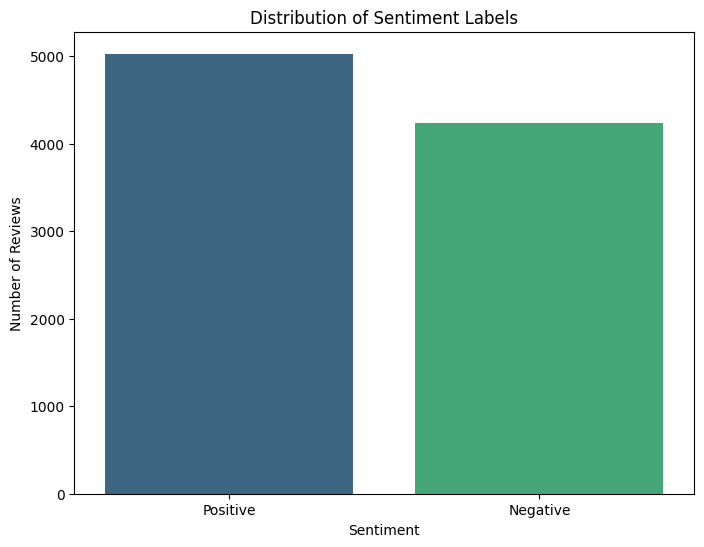

In [15]:
# Menghitung jumlah ulasan untuk setiap kategori sentimen
sentiment_counts = clean_df['sentiment'].value_counts()
display(sentiment_counts)

# Memvisualisasikan distribusi sentimen
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

#Eksplorasi Label

# Data Splitting dan Ekstraksi Fitur dengN TF-IDF

In [16]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.model_selection import train_test_split
# import pandas as pd

# # 1. Pisahkan fitur dan label (Sudah Benar)
# X = clean_df['text_akhir']
# y = clean_df['sentiment'] # Pastikan ini sudah hasil labeling dari kolom 'score'

# # 2. Ekstraksi fitur dengan TF-IDF (Sudah Bagus!)
# tfidf = TfidfVectorizer(max_features=1500, min_df=5, max_df=0.8, ngram_range=(1, 2))
# X_tfidf = tfidf.fit_transform(X)

# # --- CATATAN ML ENGINEER ---
# # Jangan gunakan .toarray() jika data kamu sangat banyak (>50.000 baris)
# # karena akan membuat memori penuh. Biarkan dalam bentuk 'Sparse Matrix'.
# # ---------------------------

# # 3. Bagi data menjadi data latih dan data uji
# # Tambahkan parameter stratify=y agar proporsi Positive/Negative di train & test SAMA.
# X_train, X_test, y_train, y_test = train_test_split(
#     X_tfidf,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# print(f"Jumlah data latihan: {X_train.shape[0]}")
# print(f"Jumlah data pengujian: {X_test.shape[0]}")

In [17]:
!pip install gensim
from gensim.models import Word2Vec
import numpy as np

# A. Siapkan data ulasan yang sudah bersih (ambil dari step7_filter)
# Word2Vec butuh input berupa list kata-kata
sentences = clean_df['step7_filter'].tolist()

# B. Latih model Word2Vec (Membuat "otak" bahasa)
# vector_size=100 artinya satu ulasan diwakili 100 angka
w2v_model = Word2Vec(sentences, vector_size=300, window=5, min_count=2, workers=4)

# C. FUNGSI GET_SENTENCE_VECTOR (Sesuai permintaanmu)
# Fungsi ini merubah list kata menjadi satu titik koordinat (vektor) rata-rata
def get_sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# D. Terapkan fungsi tersebut untuk membuat fitur X
X_w2v = np.array([get_sentence_vector(tokens, w2v_model) for tokens in clean_df['step7_filter']])
y = clean_df['sentiment'] # Ambil label yang sudah kita buat di atas
X_combined = np.hstack((X_w2v, clean_df['sentiment_score'].values.reshape(-1, 1)))
print("Teks berhasil diubah menjadi vektor Word2Vec!")
print("Ukuran X_w2v:", X_w2v.shape)
print("Ukuran X_combined:", X_combined.shape)

# Jika X_combined kolomnya 301, berarti SUDAH BENAR.

Teks berhasil diubah menjadi vektor Word2Vec!
Ukuran X_w2v: (9271, 300)
Ukuran X_combined: (9271, 301)


In [18]:
from sklearn.model_selection import train_test_split
from collections import Counter


# 1. Bagi data menjadi data Latih dan data Uji (WAJIB sebelum SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Distribusi awal (Train): {Counter(y_train)}")


Distribusi awal (Train): Counter({'Positive': 4023, 'Negative': 3393})


In [19]:
from imblearn.over_sampling import SMOTE

# 2. Terapkan SMOTE pada data Latih (X_train) saja
# SMOTE akan membuat data Neutral "buatan" agar jumlahnya sama dengan Positive
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribusi setelah SMOTE (Train): {Counter(y_train_res)}")

Distribusi setelah SMOTE (Train): Counter({'Positive': 4023, 'Negative': 4023})


# Modeling

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Membuat objek model (Settingan kamu sudah bagus!)
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    # min_samples_split=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Melatih model (PERHATIKAN: Gunakan data hasil resample SMOTE)
# Kita pakai X_train_res dan y_train_res agar kategori Neutral ikut dipelajari
random_forest.fit(X_train_res, y_train_res)
# random_forest.fit(X_train, y_train)


# 3. Prediksi (Tetap pakai X_test yang asli/original)
y_pred_test_rf = random_forest.predict(X_test)

# 4. Evaluasi
print('Random Forest + Word2Vec + SMOTE - Accuracy Test:', accuracy_score(y_test, y_pred_test_rf))
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_test_rf))

Random Forest + Word2Vec + SMOTE - Accuracy Test: 0.7428571428571429

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.69      0.80      0.74       849
    Positive       0.81      0.69      0.75      1006

    accuracy                           0.74      1855
   macro avg       0.75      0.75      0.74      1855
weighted avg       0.75      0.74      0.74      1855



In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_res)
y_test_encoded = le.transform(y_test)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

Urutan kelas: ['Negative' 'Positive']


In [23]:
from xgboost import XGBClassifier

# 1. Inisialisasi Model
xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.01,     # Belajar sangat detail
    max_depth=10,           # Pohon lebih dalam untuk menangkap pola Neutral
    subsample=0.8,          # Mengambil 80% data secara acak agar tidak overfit
    colsample_bytree=0.8,   # Mengambil 80% fitur secara acak
    objective='binary:logistic', # Changed to binary:logistic for 2 classes
    random_state=42,
    n_jobs=-1
)

# 2. Training (Pakai data SMOTE yang sudah di-encode)
xgb_model.fit(X_train_res, y_train_encoded)

# 3. Prediksi
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluasi (Ubah kembali angka ke teks label asli)
print('XGBoost Accuracy:', accuracy_score(y_test_encoded, y_pred_xgb))
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

XGBoost Accuracy: 0.7466307277628033
              precision    recall  f1-score   support

    Negative       0.69      0.80      0.74       849
    Positive       0.80      0.70      0.75      1006

    accuracy                           0.75      1855
   macro avg       0.75      0.75      0.75      1855
weighted avg       0.75      0.75      0.75      1855



In [24]:
from lightgbm import LGBMClassifier

# 1. Inisialisasi Model
lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,    # Belajar lebih lambat tapi lebih teliti
    num_leaves=128,        # Pohon lebih kompleks
    force_col_wise=True,   # Menghilangkan overhead
    class_weight='balanced',
    random_state=42
)

# 2. Training
lgbm_model.fit(X_train_res, y_train_encoded)

# 3. Prediksi
y_pred_lgbm = lgbm_model.predict(X_test)

# 4. Evaluasi
print('LightGBM Accuracy:', accuracy_score(y_test_encoded, y_pred_lgbm))
print(classification_report(y_test_encoded, y_pred_lgbm, target_names=le.classes_))

[LightGBM] [Info] Number of positive: 4023, number of negative: 4023
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 8046, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.7353099730458221
              precision    recall  f1-score   support

    Negative       0.69      0.77      0.73       849
    Positive       0.79      0.70      0.74      1006

    accuracy                           0.74      1855
   macro avg       0.74      0.74      0.74      1855
weighted avg       0.74      0.74      0.74      1855

